# Annotator model
---

In [65]:
import torch
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True  # Speed up convolutions

# Load the pre-trained Faster R-CNN and modify it for 2 classes (background, text)
annotation_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
num_classes = 2  # Background + Text
in_features = annotation_model.roi_heads.box_predictor.cls_score.in_features
annotation_model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

# Load the saved state dictionary and map it to the CPU
annotation_model.load_state_dict(torch.load('/kaggle/input/annotation_model/pytorch/default/1/annotation_model.pth', 
                                            map_location=torch.device('cpu')))

<ipython-input-65-2a45289baf1e>:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  annotation_model.load_state_dict(torch.load('/kaggle/input/annotation_model/pytorch/default

<All keys matched successfully>

In [67]:
import cv2
import torchvision.transforms as T
import matplotlib.pyplot as plt

def predict_and_visualize(model, image_path, device, threshold=0.5):
    """
    Runs object detection on an image and visualizes detected text regions.
    
    Args:
        model: Trained Faster R-CNN model
        image_path: Path to the image file
        device: 'cuda' or 'cpu'
        threshold: Confidence threshold for displaying bounding boxes
    """
    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    orig_image = image.copy()
    
    # Transform image to tensor
    transform = T.Compose([T.ToTensor()])
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Set model to evaluation mode
    model.eval()
    with torch.no_grad():
        prediction = model(image_tensor)
    
    # Extract boxes and scores
    boxes = prediction[0]['boxes'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()

    true_boxes = []
    for i, box in enumerate(boxes):
        if scores[i] > threshold:
            true_boxes.append(box)
    
    # Draw bounding boxes on the image
    for i, box in enumerate(true_boxes):
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(orig_image, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(orig_image, f"{scores[i]:.2f}", (x1, y1 - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    return image, sorted(true_boxes, key=lambda x: x[1]), orig_image

# OCR model
---

In [5]:
import torch.nn as nn

class HandwritingRecognitionModel(nn.Module):
    def __init__(self, num_characters):
        super(HandwritingRecognitionModel, self).__init__()
        
        self.cnn = nn.Sequential(
            # First CNN layer
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
            # Second CNN layer
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3),
            
            # Third CNN layer
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.3),
            
            # New fourth CNN layer
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        
        # Update LSTM input size based on new CNN output
        self.lstm_input_size = 256 * 11  # Height after CNN = 45/4 ≈ 11
        
        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size,
            hidden_size=256,
            dropout=0.5,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )
        
        self.output = nn.Linear(512, num_characters)
    
    def forward(self, x):
        # Input: (batch, height=45, width, channel=1)
        batch_size = x.size(0)
        
        # Reshape for CNN: (batch, channel, height, width)
        x = x.permute(0, 3, 1, 2)
        
        # CNN features
        x = self.cnn(x)  # Output: (batch, 256, height/4, width)
        
        # Prepare for LSTM: (batch, width, features)
        x = x.permute(0, 3, 1, 2)  # (batch, width, 256, height/4)
        x = x.reshape(batch_size, x.size(1), -1)  # (batch, sequence_len, features)
        
        # LSTM
        x, _ = self.lstm(x)
        
        # Output layer
        x = self.output(x)
        return nn.functional.log_softmax(x, dim=2)

In [64]:
import torch
import pickle

# Load the trained model
model_path = "/kaggle/input/first_model/pytorch/default/4/model.pth"  # Replace with your saved model path
model = HandwritingRecognitionModel(num_characters)  # Rebuild the model
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()

with open('/kaggle/input/first_model/pytorch/default/4/num_to_char.pkl', 'rb') as f:
    num_to_char = pickle.load(f)

num_characters = len(num_to_char)

<ipython-input-64-88b9a95f619e>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))


In [72]:
import torch
import cv2
import numpy as np

FIXED_HEIGHT = 45  # Ensure this matches training

def preprocess_crop(image, box):
    x1, y1, x2, y2 = map(int, box)
    crop = image[y1:y2, x1:x2]
    h = y2-y1
    w = x2-x1
    aspect_ratio = w / h if h != 0 else 1
    new_width = max(1, int(FIXED_HEIGHT * aspect_ratio))  # Avoid width=0
    resized = cv2.resize(crop, (new_width, FIXED_HEIGHT))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    normalized = gray.astype(np.float32) / 255.0
    normalized = np.expand_dims(normalized, axis=-1)  # (H, W, 1)
    
    return normalized


def collate_inference_images(image_tensors):
    widths = [img.shape[1] for img in image_tensors]
    max_width = max(widths)

    padded_images = []
    for img in image_tensors:
        pad_width = max_width - img.shape[1]
        padded = np.pad(img, ((0, 0), (0, pad_width), (0, 0)), mode='constant', constant_values=0)
        padded_images.append(padded)

    batch = np.stack(padded_images, axis=0)
    batch = np.transpose(batch, (0, 1, 2, 3))  # Expect (B, 1, H, W)
    
    return torch.tensor(batch, dtype=torch.float32)

def decode_predictions(preds, num_to_char):
    pred_indices = torch.argmax(preds, dim=2).detach().cpu().numpy()
    decoded = []
    for indices in pred_indices:
        prev_idx = None
        chars = []
        for idx in indices:
            if idx != prev_idx and idx != 0:  # 0 is <PAD>
                chars.append(num_to_char.get(idx, ''))
            prev_idx = idx
        decoded.append("".join(chars))
        
    return decoded

def run_inference(model, image, bboxes, num_to_char, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    image_tensors = [preprocess_crop(image, box) for box in bboxes]
    batch = collate_inference_images(image_tensors).to(device)
    batch = batch.contiguous()
    batch = batch.to(device)  # If you're using CUDA

    with torch.no_grad():
        preds = model(batch)  # Output shape: (B, T, C)
    decoded_strings = decode_predictions(preds, num_to_char)
    
    return decoded_strings


# Inference
---

In [70]:
def transcribe_handwriting(input, annotation_model, model, device, num_to_char, threshold=0.8):
    image, boxes, orig_image = predict_and_visualize(annotation_model, input, device, threshold=0.8)
    results = run_inference(model, image, boxes, num_to_char)
    return " ".join(results)

In [68]:
def detail_transcribe_handwriting(input, annotation_model, model, device, num_to_char, threshold=0.8):
    image, boxes, orig_image = predict_and_visualize(annotation_model, input, device, threshold=0.8)
    results = run_inference(model, image, boxes, num_to_char)
    plt.figure(figsize=(12, 8))
    plt.imshow(orig_image)
    plt.axis("off")
    plt.show()
    for i, prediction in enumerate(results):
        print(f"Prediction {i + 1}: {prediction}")
        x1, y1, x2, y2 = map(int, boxes[i])
        cropped_image = image[y1:y2, x1:x2]
        plt.imshow(cropped_image, cmap='gray')
        plt.show()

In [77]:
input = '/kaggle/input/complete-resized-journal-scans/resized_journal_scans/IMG_6242.JPG'

In [78]:
import time

start = time.time()
text = transcribe_handwriting(input, annotation_model, model, device, num_to_char, threshold=0.8)
print(text)
print('\nInference time:', round(time.time() - start, 2), 'seconds')

 Grateful 02/08 /s  Feel like I havent beeem veny  gratful recently. So here we gos  . My family is, healthy and happp I have friends that I can meet  and mesage. I am healthy, b young strong, athletic, smart and decent looking. I have ak job that is well paid, easy  comfortable, somedimes challenging  and full of opportunities to prork I am able to travel freely  and affordably. I am abld b  to save money, invest freely and  make extra money pssevely  , I have access dot t infinit  entertinment and knowled at my finger tips. I live ink a toime and a place where  knowledge and hard work  , reward appopriately. I do not  lack food, shelter ormoney.  . Every day I work to get betterk  live more comfortably, thereford I focus on the next problemfobstacle  in line. So focusing on this can b get me down, but one should not  forkget what one has 

Inference time: 8.21 seconds


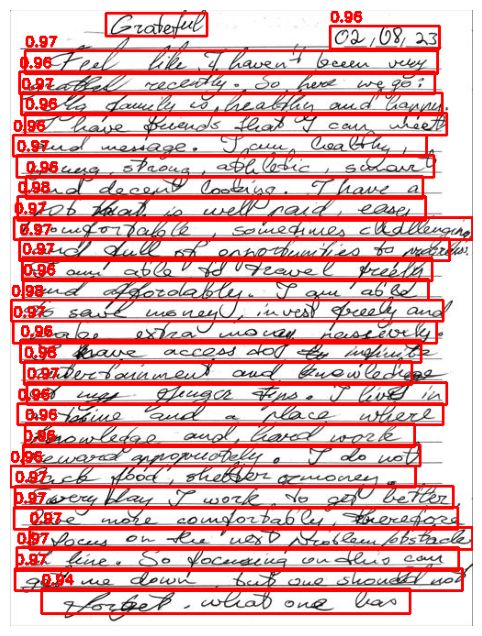

Prediction 1:  Grateful


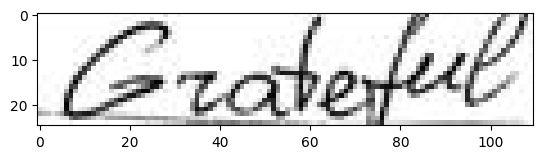

Prediction 2: 02/08 /s


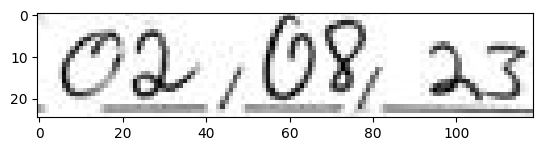

Prediction 3:  Feel like I havent beeem veny 


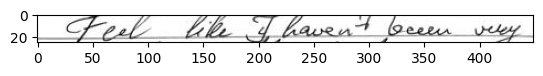

Prediction 4: gratful recently. So here we gos 


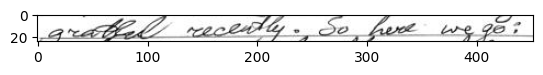

Prediction 5: . My family is, healthy and happp


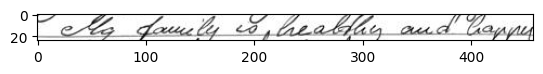

Prediction 6: I have friends that I can meet


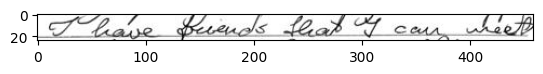

Prediction 7:  and mesage. I am healthy, b


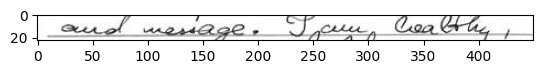

Prediction 8: young strong, athletic, smart


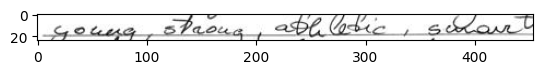

Prediction 9: and decent looking. I have ak


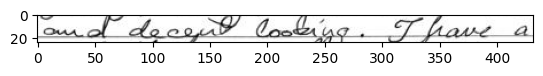

Prediction 10: job that is well paid, easy 


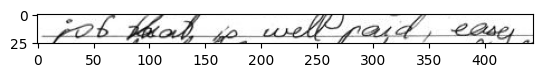

Prediction 11: comfortable, somedimes challenging


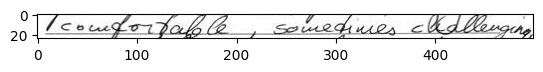

Prediction 12:  and full of opportunities to prork


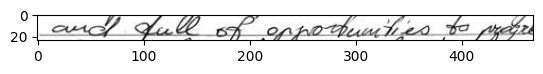

Prediction 13: I am able to travel freely


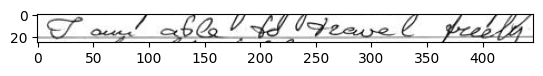

Prediction 14:  and affordably. I am abld b


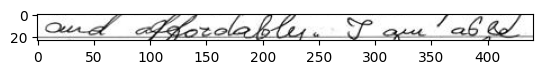

Prediction 15:  to save money, invest freely and


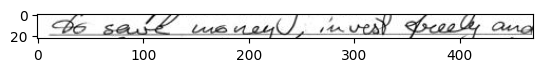

Prediction 16:  make extra money pssevely 


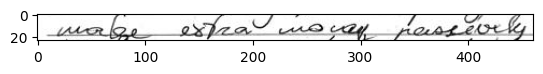

Prediction 17: , I have access dot t infinit


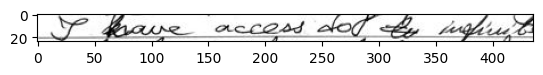

Prediction 18:  entertinment and knowled


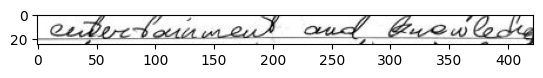

Prediction 19: at my finger tips. I live ink


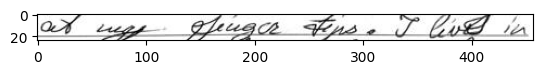

Prediction 20: a toime and a place where 


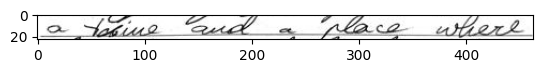

Prediction 21: knowledge and hard work 


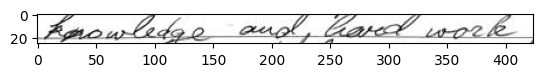

Prediction 22: , reward appopriately. I do not


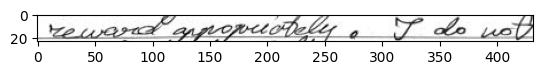

Prediction 23:  lack food, shelter ormoney. 


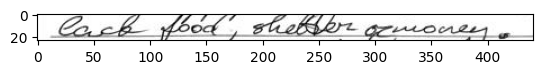

Prediction 24: . Every day I work to get betterk


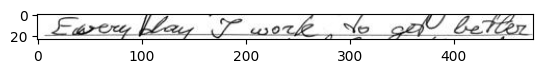

Prediction 25:  live more comfortably, thereford


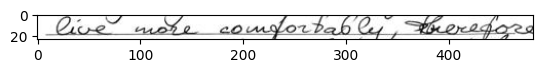

Prediction 26: I focus on the next problemfobstacle


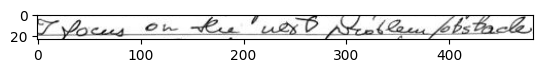

Prediction 27:  in line. So focusing on this can b


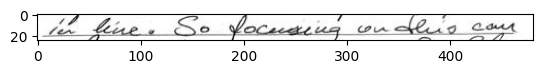

Prediction 28: get me down, but one should not


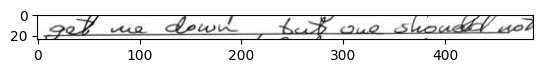

Prediction 29:  forkget what one has 


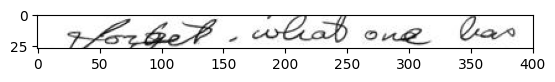

 Grateful 02/08 /s  Feel like I havent beeem veny  gratful recently. So here we gos  . My family is, healthy and happp I have friends that I can meet  and mesage. I am healthy, b young strong, athletic, smart and decent looking. I have ak job that is well paid, easy  comfortable, somedimes challenging  and full of opportunities to prork I am able to travel freely  and affordably. I am abld b  to save money, invest freely and  make extra money pssevely  , I have access dot t infinit  entertinment and knowled at my finger tips. I live ink a toime and a place where  knowledge and hard work  , reward appopriately. I do not  lack food, shelter ormoney.  . Every day I work to get betterk  live more comfortably, thereford I focus on the next problemfobstacle  in line. So focusing on this can b get me down, but one should not  forkget what one has 

Inference time: 12.75 seconds


In [79]:
start = time.time()
detail_transcribe_handwriting(input, annotation_model, model, device, num_to_char, threshold=0.8)
print(text)
print('\nInference time:', round(time.time() - start, 2), 'seconds')